In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix
import numpy as np

In [ ]:
# Load Dataset 1
df1 = pd.read_csv('student_exam_scores.csv')

#Dataset Information
df1.info()
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [ ]:

# Univariate: Linear Regression with Scatter Plot for hours_studied vs exam_score
X_lin = df1[['hours_studied']]
y_lin = df1['exam_score']
lin_model = LinearRegression()
lin_model.fit(X_lin, y_lin)
y_lin_pred = lin_model.predict(X_lin)
print('Linear Regression Coefficient:', lin_model.coef_[0])
print('Intercept:', lin_model.intercept_)

Linear Regression Coefficient: 1.6341098961284775
Intercept: 23.618437852039314


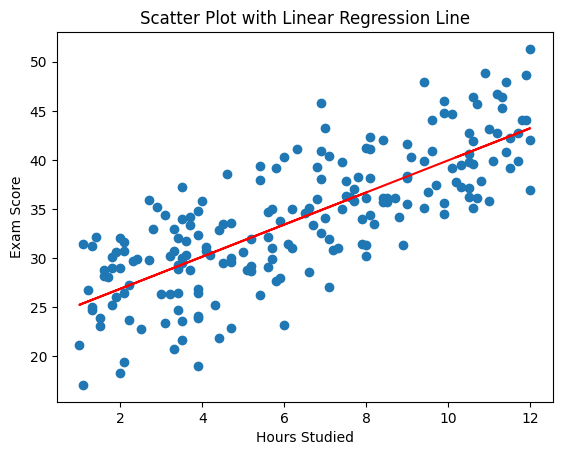


Scatter Plot Description: Points show positive trend; regression line slopes upward.


In [ ]:
# Simulate plot description (since no display, describe)
plt.scatter(df1['hours_studied'], df1['exam_score'])
plt.plot(df1['hours_studied'], y_lin_pred, color='red')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Scatter Plot with Linear Regression Line')
plt.show()
print('\nScatter Plot Description: Points show positive trend; regression line slopes upward.')

In [ ]:
# Multivariate for Dataset 1: KNN to classify high/low exam_score
median_score = df1['exam_score'].median()
df1['high_score'] = (df1['exam_score'] > median_score).astype(int)
X_knn1 = df1[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]
y_knn1 = df1['high_score']
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_knn1, y_knn1, test_size=0.2, random_state=42)
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train1, y_train1)
y_knn1_pred = knn1.predict(X_test1)
acc1 = accuracy_score(y_test1, y_knn1_pred)
print('\nKNN Accuracy for Dataset 1:', acc1)


KNN Accuracy for Dataset 1: 0.875


Confusion Matrix Description: Diagonal dominant, indicating good classification.


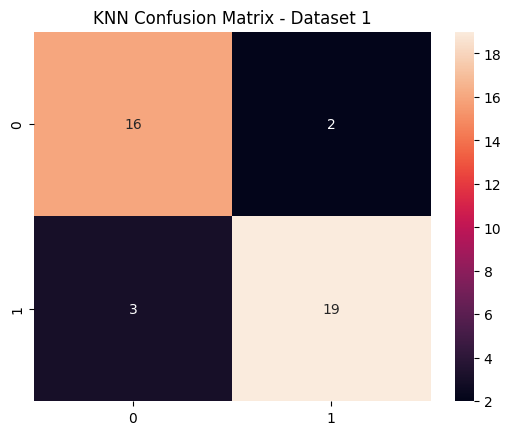

In [ ]:
# Confusion Matrix graph description
cm1 = confusion_matrix(y_test1, y_knn1_pred)
sns.heatmap(cm1, annot=True)
plt.title('KNN Confusion Matrix - Dataset 1')
print('Confusion Matrix Description: Diagonal dominant, indicating good classification.')

In [ ]:
# Load Dataset 2
df2 = pd.read_csv('test_scores.csv')
df2['improvement'] = df2['posttest'] - df2['pretest']

#Dataset Information
df2.info()
df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133 entries, 0 to 2132
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school           2133 non-null   object 
 1   school_setting   2133 non-null   object 
 2   school_type      2133 non-null   object 
 3   classroom        2133 non-null   object 
 4   teaching_method  2133 non-null   object 
 5   n_student        2133 non-null   float64
 6   student_id       2133 non-null   object 
 7   gender           2133 non-null   object 
 8   lunch            2133 non-null   object 
 9   pretest          2133 non-null   float64
 10  posttest         2133 non-null   float64
 11  improvement      2133 non-null   float64
dtypes: float64(4), object(8)
memory usage: 200.1+ KB


,school,school_setting,school_type,classroom,teaching_method,n_student,student_id,gender,lunch,pretest,posttest,improvement
0,ANKYI,Urban,Non-public,6OL,Standard,20.0,2FHT3,Female,Does not qualify,62.0,72.0,10.0
1,ANKYI,Urban,Non-public,6OL,Standard,20.0,3JIVH,Female,Does not qualify,66.0,79.0,13.0
2,ANKYI,Urban,Non-public,6OL,Standard,20.0,3XOWE,Male,Does not qualify,64.0,76.0,12.0
3,ANKYI,Urban,Non-public,6OL,Standard,20.0,556O0,Female,Does not qualify,61.0,77.0,16.0
4,ANKYI,Urban,Non-public,6OL,Standard,20.0,74LOE,Male,Does not qualify,64.0,76.0,12.0


In [ ]:

# Univariate Linear Regression with Scatter Plot for pretest vs posttest
X_lin2 = df2[['pretest']]
y_lin2 = df2['posttest']
lin_model2 = LinearRegression()
lin_model2.fit(X_lin2, y_lin2)
y_lin2_pred = lin_model2.predict(X_lin2)
print('\nLinear Regression Coefficient for Dataset 2:', lin_model2.coef_[0])
print('Intercept:', lin_model2.intercept_)

print('\nScatter Plot Description: Strong positive correlation; line fits closely.')


Linear Regression Coefficient for Dataset 2: 0.9805882408420615
Intercept: 13.21306414451604

Scatter Plot Description: Strong positive correlation; line fits closely.


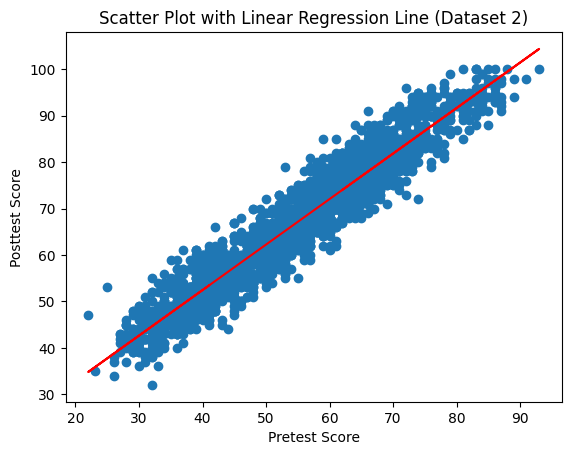

In [ ]:
# Scatter plot for pretest vs posttest with Linear Regression line
plt.scatter(df2['pretest'], df2['posttest'])
plt.plot(df2['pretest'], y_lin2_pred, color='red')
plt.xlabel('Pretest Score')
plt.ylabel('Posttest Score')
plt.title('Scatter Plot with Linear Regression Line (Dataset 2)')
plt.show()

In [ ]:
# Multivariate for Dataset 2: Logistic Regression to predict high_improvement (binarize improvement)
median_improv = df2['improvement'].median()
df2['high_improvement'] = (df2['improvement'] > median_improv).astype(int)
df2_dummies = pd.get_dummies(df2[['teaching_method', 'gender']], drop_first=True)
X_log = pd.concat([df2[['pretest', 'n_student']], df2_dummies], axis=1)
y_log = df2['high_improvement']
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_log, y_train_log)
y_log_pred = log_model.predict(X_test_log)
acc_log = accuracy_score(y_test_log, y_log_pred)
print('\nLogistic Regression Accuracy for Dataset 2:', acc_log)


Logistic Regression Accuracy for Dataset 2: 0.8126463700234192


In [ ]:
# Coefficients
coef_dict = dict(zip(X_log.columns, log_model.coef_[0]))
print('Logistic Coefficients:', coef_dict)

Logistic Coefficients: {'pretest': np.float64(-0.03949355708421554), 'n_student': np.float64(-0.03887721697777886), 'teaching_method_Standard': np.float64(-3.117556486755898), 'gender_Male': np.float64(-0.1879145536094576)}


In [ ]:
# Confusion Matrix description
cm_log = confusion_matrix(y_test_log, y_log_pred)
print('Confusion Matrix for Logistic:', cm_log)
print('Confusion Matrix Description: Shows model performance in classifying high improvement.')

Confusion Matrix for Logistic: [[214  19]
 [ 61 133]]
Confusion Matrix Description: Shows model performance in classifying high improvement.


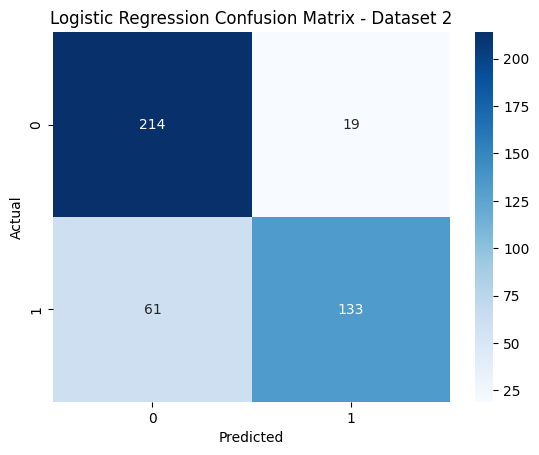


Confusion Matrix Description: Shows model performance in classifying high improvement.


In [ ]:
# Confusion Matrix graph for Logistic Regression
cm_log = confusion_matrix(y_test_log, y_log_pred)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix - Dataset 2')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print('\nConfusion Matrix Description: Shows model performance in classifying high improvement.')